# QUESTÕES

5. Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que 
antecedem quedas de desempenho acadêmico ou de engajamento? 
6. Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas 
(IPP) confirmam ou contradizem a defasagem identificada pelo IAN? 

# Import

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/vbomura/tc5/main/Codigos/base_anos_limpo.xlsx"
dfBaseAnosLimpos = pd.read_excel(url)
dfBaseAnosLimpos

,ra,fase_original,turma,nome_anonimizado,ano_nasc_original,idade_original,genero,ano_ingresso,instituicao_de_ensino,pedra,...,ipv,ian,fase_ideal_original,defasagem,ano_aba,ano_nascimento,fase,fase_ideal,ipp,idade
0,RA-1,7,A,Aluno-1,2003,19,Feminino,2016,Escola Pública,Quartzo,...,7.278,5.0,Fase 8 (Universitários),-1,2022,2003,FASE 7,FASE 8,NaN,19
1,RA-2,7,A,Aluno-2,2005,17,Feminino,2017,Rede Decisão,Ametista,...,6.778,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,FASE 7,NaN,17
2,RA-3,7,A,Aluno-3,2005,17,Feminino,2016,Rede Decisão,Ágata,...,7.556,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,FASE 7,NaN,17
3,RA-4,7,A,Aluno-4,2005,17,Masculino,2017,Rede Decisão,Quartzo,...,5.278,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,FASE 7,NaN,17
4,RA-5,7,A,Aluno-5,2005,17,Feminino,2016,Rede Decisão,Ametista,...,7.389,10.0,Fase 7 (3º EM),0,2022,2005,FASE 7,FASE 7,NaN,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2840,RA-291,7E,7E,Aluno-291,2009-01-17 00:00:00,15,Masculino,2022,Privada - Programa de Apadrinhamento,Ametista,...,7.500,10.0,Fase 5 (1° EM),2,2024,2009,FASE 7,FASE 5,7.5,15
2841,RA-86,7E,7E,Aluno-86,2006-10-04 00:00:00,18,Masculino,2021,Privada *Parcerias com Bolsa 100%,Ametista,...,7.500,10.0,Fase 7 (3° EM),0,2024,2006,FASE 7,FASE 7,7.5,18
2842,RA-143,7E,7E,Aluno-143,2009-08-01 00:00:00,15,Masculino,2021,Privada - Programa de Apadrinhamento,Ametista,...,7.500,10.0,Fase 5 (1° EM),2,2024,2009,FASE 7,FASE 5,7.5,15
2843,RA-166,7E,7E,Aluno-166,2008-06-03 00:00:00,16,Masculino,2021,Privada *Parcerias com Bolsa 100%,Topázio,...,7.500,10.0,Fase 6 (2° EM),1,2024,2008,FASE 7,FASE 6,7.5,16


In [3]:
dfBaseAnosLimpos.columns

Index(['ra', 'fase_original', 'turma', 'nome_anonimizado', 'ano_nasc_original',
       'idade_original', 'genero', 'ano_ingresso', 'instituicao_de_ensino',
       'pedra', 'inde', 'no_av', 'iaa', 'ieg', 'ips', 'ida', 'mat', 'por',
       'ing', 'ipv', 'ian', 'fase_ideal_original', 'defasagem', 'ano_aba',
       'ano_nascimento', 'fase', 'fase_ideal', 'ipp', 'idade'],
      dtype='object')

# Cores

In [4]:
# Dicionário de Identidade Visual do Projeto
CORES_PROJETO = {
    # --- Indicadores de Performance (Principais) ---
    'inde': '#1f77b4', # Azul escuro (Indicador Geral)
    'iaa':  '#aec7e8', # Azul claro
    'ieg':  '#ff7f0e', # Laranja (Engajamento)
    'ips':  '#ffbb78', # Laranja claro (Psicossocial)
    'ida':  '#2ca02c', # Verde (Aprendizagem)
    'ipp':  "#8a91df", # Verde claro (Psicopedagógico)
    'ipv':  '#d62728', # Vermelho (Ponto de Virada)
    'ian':  '#9467bd', # Roxo (Adequação ao Nível)
    'defasagem': '#c5b0d5', # Roxo claro
    
    # --- Matérias Específicas ---
    'mat': '#8c564b', # Marrom (Matemática)
    'por': '#c49c94', # Marrom claro (Português)
    'ing': '#e377c2', # Rosa (Inglês)
    
    # --- Dados Demográficos e Registro ---
    'genero': '#f7b6d2', # Rosa claro
    'idade':  '#7f7f7f', # Cinza
    'pedra':  '#bcbd22', # Oliva (Conceito da escola)
    'fase':   '#dbdb8d', # Oliva claro
    'no_av':  '#17becf'  # Ciano (Número de avaliações)
}

# Colunas que não possuem cor fixa (Geralmente identificadores)
# 'ra', 'ano_aba', 'ano_nasc_original', etc.

In [5]:
# Responder a pergiunta 5
# Se o IPS antecedem quedas de notas ou engajamento
# Separar por anos e depois fazer um merge por aluno


df_duplicados = dfBaseAnosLimpos.copy()

df_duplicados = df_duplicados[df_duplicados['ra'].duplicated(keep=False)]
df_duplicados.sort_values(by=['ra', 'ano_aba'], ascending=[True, True], inplace=True)
df_duplicados.round(2)
df_duplicados

,ra,fase_original,turma,nome_anonimizado,ano_nasc_original,idade_original,genero,ano_ingresso,instituicao_de_ensino,pedra,...,ipv,ian,fase_ideal_original,defasagem,ano_aba,ano_nascimento,fase,fase_ideal,ipp,idade
1072,RA-1000,NaN,ALFA U - G2/G3,Aluno-1000,4/20/2015,8,Feminino,2023,Pública,Ametista,...,8.920000,10.0,ALFA (1° e 2° ano),0,2023,2015,ALFA,ALFA,6.250000,8
2142,RA-1000,1N,1N,Aluno-1000,2015-04-20 00:00:00,9,Feminino,2023,Pública,Topázio,...,7.835000,10.0,Fase 1 (3° e 4° ano),0,2024,2015,FASE 1,FASE 1,8.125000,9
1074,RA-1001,NaN,ALFA U - G2/G3,Aluno-1001,3/13/2014,9,Feminino,2023,Pública,Topázio,...,9.170000,5.0,Fase 1 (3° e 4° ano),-1,2023,2014,ALFA,FASE 1,7.500000,9
2144,RA-1001,1N,1N,Aluno-1001,2014-03-13 00:00:00,10,Feminino,2023,Pública,Ametista,...,7.920000,5.0,Fase 2 (5° e 6° ano),-1,2024,2014,FASE 1,FASE 2,7.916667,10
1075,RA-1002,NaN,ALFA U - G2/G3,Aluno-1002,7/13/2014,9,Feminino,2023,Pública,Ametista,...,8.920000,5.0,Fase 1 (3° e 4° ano),-1,2023,2014,ALFA,FASE 1,6.250000,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,RA-991,1A,1A,Aluno-991,2014-04-30 00:00:00,10,Feminino,2023,Pública,Ametista,...,6.723333,5.0,Fase 2 (5° e 6° ano),-1,2024,2014,FASE 1,FASE 2,7.500000,10
1063,RA-994,NaN,ALFA T - G2/G3,Aluno-994,12/18/2014,8,Feminino,2023,Pública,Ametista,...,7.265000,10.0,ALFA (1° e 2° ano),0,2023,2014,ALFA,ALFA,5.625000,9
1968,RA-994,ALFA,ALFA T - G2/G3,Aluno-994,2014-12-18 00:00:00,9,Feminino,2023,Pública,Ametista,...,7.330000,5.0,Fase 1 (3° e 4° ano),-1,2024,2014,ALFA,FASE 1,6.875000,10
1064,RA-995,NaN,ALFA T - G2/G3,Aluno-995,2012-02-04 00:00:00,1900-01-11 00:00:00,Feminino,2023,Pública,Ágata,...,7.180000,5.0,Fase 2 (5° e 6° ano),-2,2023,2012,ALFA,FASE 2,6.250000,11


In [6]:
colunas_desejadas = [
    'ra', 'ano_aba',
    'ips', 'ieg', 'ida'
]

df_redusido = df_duplicados[colunas_desejadas]
df_redusido

,ra,ano_aba,ips,ieg,ida
1072,RA-1000,2023,3.770,9.400000,7.00
2142,RA-1000,2024,6.260,9.545455,7.75
1074,RA-1001,2023,7.520,9.100000,7.80
2144,RA-1001,2024,7.510,9.347826,7.75
1075,RA-1002,2023,7.520,9.700000,7.00
...,...,...,...,...,...
1989,RA-991,2024,6.260,8.181818,6.50
1063,RA-994,2023,3.770,9.400000,6.00
1968,RA-994,2024,6.880,9.532609,8.25
1064,RA-995,2023,3.770,7.900000,5.10


In [7]:
anos = df_redusido['ano_aba'].value_counts().reset_index()
anos

,ano_aba,count
0,2023,814
1,2024,689
2,2022,581


In [8]:
df_22 = df_redusido.query('ano_aba == 2022')
df_23 = df_redusido.query('ano_aba == 2023')
df_24 = df_redusido.query('ano_aba == 2024')

def renomenado_colunas(df, n):
    df = df.rename(columns={
        'ips':'ips' + '_' + n,
        'ieg':'ieg' + '_' + n,
        'ida':'ida' + '_' + n
    })
    
    return df

df_22 = renomenado_colunas(df_22, '22')
df_23 = renomenado_colunas(df_23, '23')
df_24 = renomenado_colunas(df_24, '24')
df_22

,ra,ano_aba,ips_22,ieg_22,ida_22
102,RA-103,2022,7.5,8.7,7.3
103,RA-104,2022,7.5,8.7,3.7
105,RA-106,2022,9.4,8.0,7.4
106,RA-107,2022,7.5,6.4,4.6
107,RA-108,2022,5.0,7.7,5.0
...,...,...,...,...,...
92,RA-93,2022,8.1,9.7,8.5
93,RA-94,2022,8.1,9.6,7.7
95,RA-96,2022,6.9,7.8,6.7
97,RA-98,2022,9.4,10.0,8.5


In [9]:
print(f"Totald e linhas 22 {len(df_22)}")
print(f"Totald e linhas 23 {len(df_23)}")
print(f"Totald e linhas 24 {len(df_24)}")

Totald e linhas 22 581
Totald e linhas 23 814
Totald e linhas 24 689


In [10]:
# merge das tabelas separadas

# df_merge_ano = pd.merge(
#     df_22,
#     df_23,
#     on='ra',
#     how='left'
# )

# df_merge_ano = pd.merge(
#     df_merge_ano,
#     df_24,
#     on='ra',
#     how='left'
# )


df_merge_ano = pd.merge(
    df_23,
    df_22,
    on='ra',
    how='left'
)

df_merge_ano = pd.merge(
    df_merge_ano,
    df_24,
    on='ra',
    how='left'
)


df_merge_ano = df_merge_ano.round(2)
df_merge_ano


,ra,ano_aba_x,ips_23,ieg_23,ida_23,ano_aba_y,ips_22,ieg_22,ida_22,ano_aba,ips_24,ieg_24,ida_24
0,RA-1000,2023,3.77,9.4,7.0,NaN,NaN,NaN,NaN,2024.0,6.26,9.55,7.75
1,RA-1001,2023,7.52,9.1,7.8,NaN,NaN,NaN,NaN,2024.0,7.51,9.35,7.75
2,RA-1002,2023,7.52,9.7,7.0,NaN,NaN,NaN,NaN,2024.0,7.51,7.83,9.25
3,RA-1003,2023,7.52,8.5,4.0,NaN,NaN,NaN,NaN,2024.0,7.51,8.69,8.25
4,RA-1004,2023,7.52,9.6,7.9,NaN,NaN,NaN,NaN,2024.0,7.51,9.25,7.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...
809,RA-99,2023,5.63,8.3,4.5,2022.0,7.5,6.3,5.0,NaN,NaN,NaN,NaN
810,RA-990,2023,7.52,8.5,7.8,NaN,NaN,NaN,NaN,2024.0,7.51,7.50,8.00
811,RA-991,2023,3.14,9.1,7.7,NaN,NaN,NaN,NaN,2024.0,6.26,8.18,6.50
812,RA-994,2023,3.77,9.4,6.0,NaN,NaN,NaN,NaN,2024.0,6.88,9.53,8.25


In [11]:
df_merge_ano['VAR_IDA_2023'] = df_merge_ano['ida_23'] - df_merge_ano['ida_22']
df_merge_ano['VAR_IEG_2023'] = df_merge_ano['ieg_23'] - df_merge_ano['ieg_22']

# 3. Identificar padrões: Alunos que tiveram queda no IPS primeiro
# Vamos filtrar alunos onde o IPS de 2020 era baixo ou caiu
# E ver se a VAR_IDA_2021 foi negativa (queda)
alunos_queda_ida = df_merge_ano[df_merge_ano['VAR_IDA_2023'] < 0]

# 4. Comparação de Médias
# Alunos que tiveram queda no desempenho tinham um IPS menor no ano anterior?
media_ips_quem_caiu = alunos_queda_ida['ips_22'].mean()
media_ips_quem_subiu = df_merge_ano[df_merge_ano['VAR_IDA_2023'] >= 0]['ips_22'].mean()

print("Analise IDA")
print(f"Média IPS (2022) de quem caiu em 2023: {media_ips_quem_caiu:.2f}")
print(f"Média IPS (2022) de quem subiu em 2023: {media_ips_quem_subiu:.2f}")

#--------------------------------------------------------------
print("-"*60)

alunos_queda_ieg = df_merge_ano[df_merge_ano['VAR_IEG_2023'] < 0]

# 4. Comparação de Médias
# Alunos que tiveram queda no desempenho tinham um IPS menor no ano anterior?
media_ips_quem_caiu = alunos_queda_ieg['ips_22'].mean()
media_ips_quem_subiu = df_merge_ano[df_merge_ano['VAR_IEG_2023'] >= 0]['ips_22'].mean()

print("Analise IEG")
print(f"Média IPS (2022) de quem caiu em 2023: {media_ips_quem_caiu:.2f}")
print(f"Média IPS (2022) de quem subiu em 2023: {media_ips_quem_subiu:.2f}")

Analise IDA
Média IPS (2022) de quem caiu em 2023: 6.82
Média IPS (2022) de quem subiu em 2023: 6.92
------------------------------------------------------------
Analise IEG
Média IPS (2022) de quem caiu em 2023: 6.91
Média IPS (2022) de quem subiu em 2023: 6.85


In [12]:
# Criando um subset sem nulos para uma correlação limpa
df_limpo = df_merge_ano.dropna(subset=['ips_22', 'VAR_IDA_2023', 'VAR_IEG_2023'])

# Correlação de Spearman (avalia se as variáveis se movem na mesma direção)
corr_ida = df_limpo['ips_22'].corr(df_limpo['VAR_IDA_2023'], method='spearman')
corr_ieg = df_limpo['ips_22'].corr(df_limpo['VAR_IEG_2023'], method='spearman')

print(f"Correlação IPS 2022 vs Evolução IDA 2023: {corr_ida:.4f}")
print(f"Correlação IPS 2022 vs Evolução IEG 2023: {corr_ieg:.4f}")

Correlação IPS 2022 vs Evolução IDA 2023: 0.0256
Correlação IPS 2022 vs Evolução IEG 2023: -0.0273


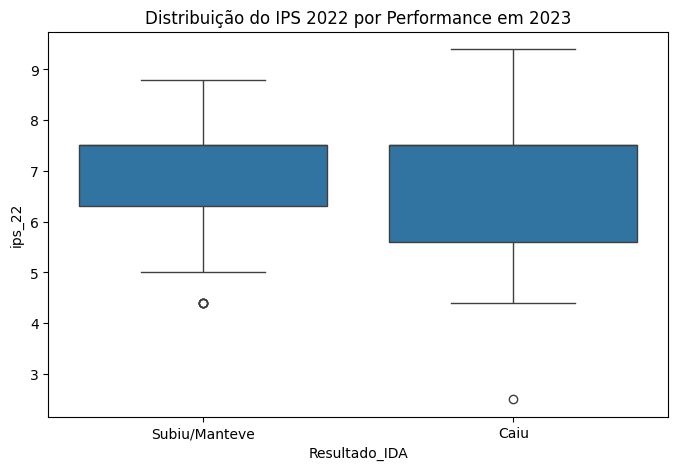

In [13]:
# Criando uma coluna categórica para o gráfico
df_merge_ano['Resultado_IDA'] = 'Subiu/Manteve'
df_merge_ano.loc[df_merge_ano['VAR_IDA_2023'] < 0, 'Resultado_IDA'] = 'Caiu'

plt.figure(figsize=(8, 5))
sns.boxplot(x='Resultado_IDA', y='ips_22', data=df_merge_ano)
plt.title('Distribuição do IPS 2022 por Performance em 2023')
plt.show()

C:\Users\Pedro\AppData\Local\Temp\ipykernel_7764\2750597293.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


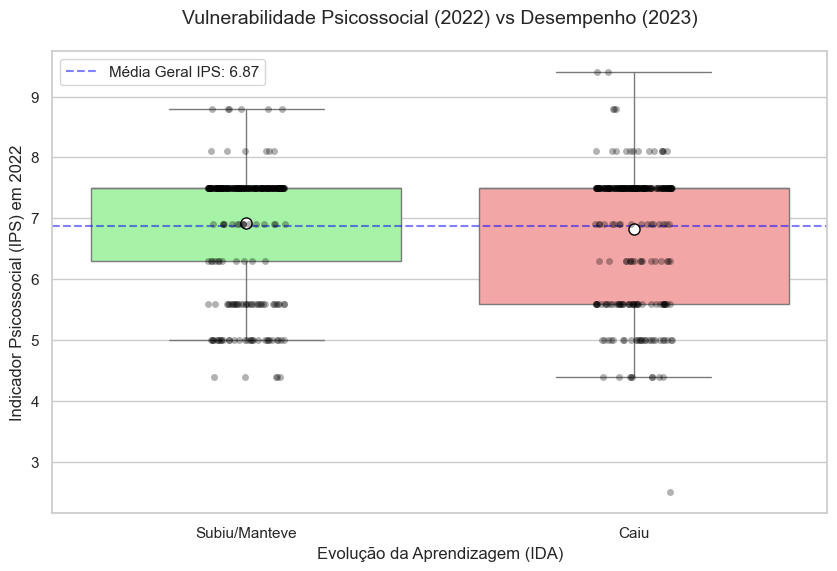

In [14]:
# 1. Definindo o estilo e cores
sns.set_theme(style="whitegrid")
paleta_cores = {"Caiu": "#ff9999", "Subiu/Manteve": "#99ff99"}

plt.figure(figsize=(10, 6))

# 2. Criando o Boxplot com a média visível (showmeans)
ax = sns.boxplot(
    x='Resultado_IDA', 
    y='ips_22', 
    data=df_merge_ano, 
    palette=paleta_cores,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
    fliersize=0 # Escondemos os outliers do boxplot para não sobrepor com o stripplot abaixo
)

# 3. Sobrepondo com Stripplot para ver a densidade (os pontos dos alunos)
sns.stripplot(
    x='Resultado_IDA', 
    y='ips_22', 
    data=df_merge_ano, 
    color="black", 
    alpha=0.3, # Transparência para não poluir
    jitter=True
)

# 4. Melhorando títulos e rótulos
plt.title('Vulnerabilidade Psicossocial (2022) vs Desempenho (2023)', fontsize=14, pad=20)
plt.xlabel('Evolução da Aprendizagem (IDA)', fontsize=12)
plt.ylabel('Indicador Psicossocial (IPS) em 2022', fontsize=12)

# Adicionando uma linha horizontal na média geral para referência
media_geral = df_merge_ano['ips_22'].mean()
plt.axhline(media_geral, color='blue', linestyle='--', alpha=0.5, label=f'Média Geral IPS: {media_geral:.2f}')
plt.legend()

plt.show()

C:\Users\Pedro\AppData\Local\Temp\ipykernel_7764\1146599816.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


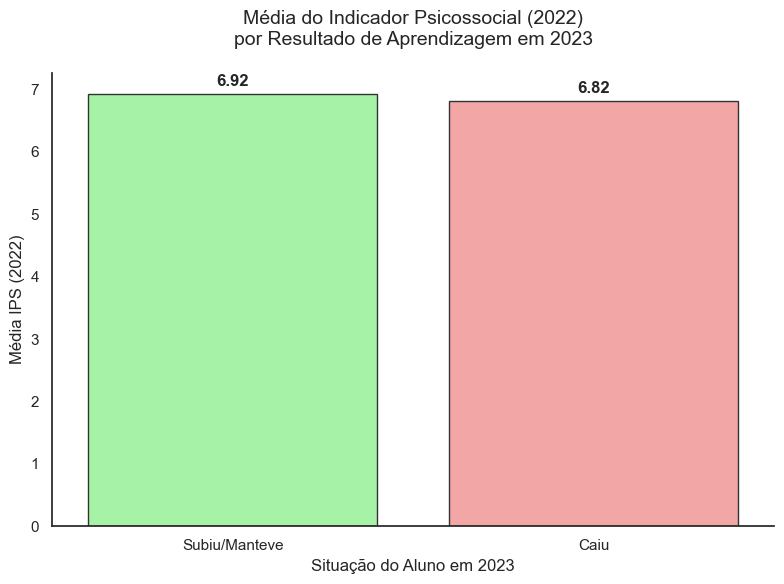

In [28]:
# Estilo limpo
sns.set_theme(style="white")
paleta_suave = {"Caiu": "#ff9999", "Subiu/Manteve": "#99ff99"}

plt.figure(figsize=(8, 6))

# Criando o gráfico de barras focado na MÉDIA
ax = sns.barplot(
    x='Resultado_IDA', 
    y='ips_22', 
    data=df_merge_ano, 
    palette=paleta_suave,
    errorbar=None, # Remove as linhas de erro para simplificar a visão
    edgecolor="0.2"
)

# Adicionando os números (rótulos) em cima das barras para facilitar a leitura
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

# Ajustes finais para clareza
plt.title('Média do Indicador Psicossocial (2022)\npor Resultado de Aprendizagem em 2023', fontsize=14, pad=20)
plt.xlabel('Situação do Aluno em 2023', fontsize=12)
plt.ylabel('Média IPS (2022)', fontsize=12)

# Remove as bordas desnecessárias (deixa o gráfico "aberto")
sns.despine()

plt.tight_layout()
plt.show()

# Resposta 5

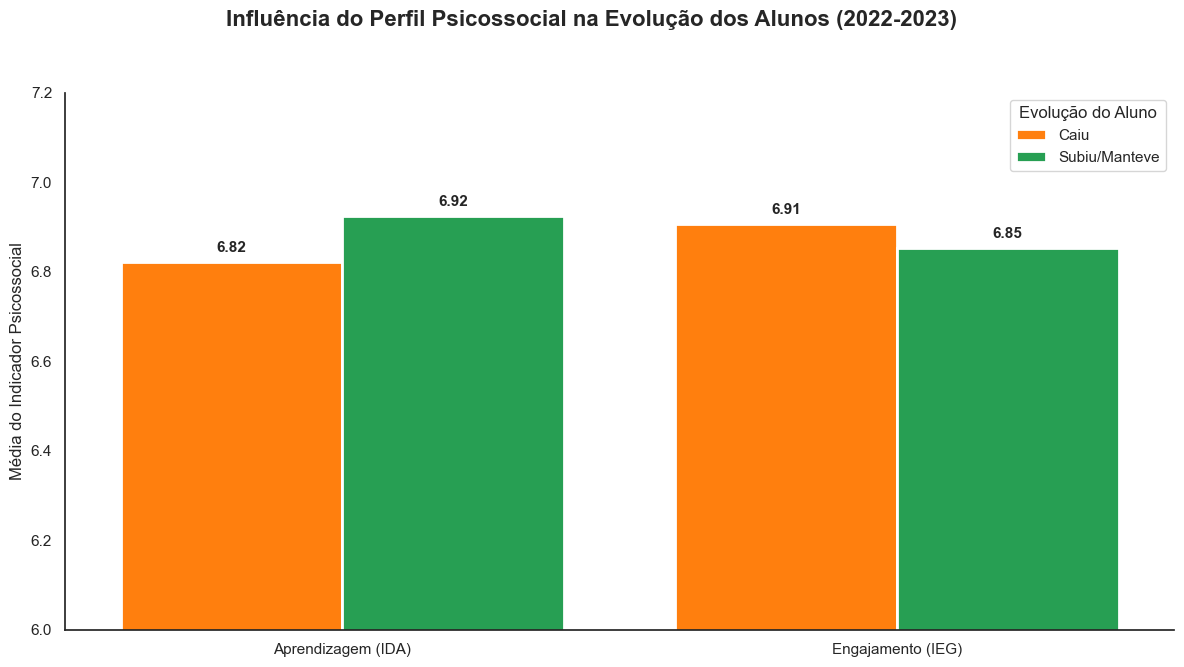

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparando os dados (Mantendo sua lógica)
media_ida = df_merge_ano.groupby('Resultado_IDA')['ips_22'].mean().reset_index()
media_ida['Tipo'] = 'Aprendizagem (IDA)'

df_merge_ano['Resultado_IEG'] = 'Subiu/Manteve'
df_merge_ano.loc[df_merge_ano['VAR_IEG_2023'] < 0, 'Resultado_IEG'] = 'Caiu'

media_ieg = df_merge_ano.groupby('Resultado_IEG')['ips_22'].mean().reset_index()
media_ieg['Tipo'] = 'Engajamento (IEG)'
media_ieg.columns = ['Resultado_IDA', 'ips_22', 'Tipo'] 

df_plot = pd.concat([media_ida, media_ieg])

# 2. Configuração Visual com as cores do seu outro gráfico
sns.set_theme(style="white")

# Usando EXATAMENTE as suas variáveis de cor
cor_abaixo = '#279F53'  # O seu verde
cor_acima = '#ff7f0e'   # O seu laranja

# Mapeando: Caiu (ruim) = Laranja | Subiu (bom) = Verde
paleta_exata = {
    "Caiu": cor_acima, 
    "Subiu/Manteve": cor_abaixo
}

plt.figure(figsize=(12, 7))

# O segredo para a cor não mudar é o 'saturation=1'
ax = sns.barplot(
    data=df_plot, 
    x='Tipo', 
    y='ips_22', 
    hue='Resultado_IDA', 
    palette=paleta_exata, 
    edgecolor="white", 
    linewidth=2,
    saturation=1  # <--- ISSO impede o Seaborn de desbotar o seu laranja/verde
)

# 3. Ajustando o Eixo Y
plt.ylim(6.0, 7.2)

# 4. Rótulos de dados
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 10), 
                    textcoords = 'offset points',
                    fontsize=11, fontweight='bold')

# 5. Títulos
plt.suptitle('Influência do Perfil Psicossocial na Evolução dos Alunos (2022-2023)', 
             fontsize=16, fontweight='bold', y=0.98)

plt.ylabel('Média do Indicador Psicossocial', fontsize=12)
plt.xlabel('', fontsize=12)
plt.legend(title='Evolução do Aluno', loc='upper right')

sns.despine()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [65]:
# Vamos identificar o limite dos 10% menores valores de IPS em 2022
limite_critico = df_merge_ano['ips_22'].quantile(0.10)

# Filtrar apenas os alunos que estavam nesse grupo crítico
grupo_critico = df_merge_ano[df_merge_ano['ips_22'] <= limite_critico]

# Ver qual a porcentagem de queda de performance NESSE grupo específico
taxa_queda_critica = (grupo_critico['VAR_IDA_2023'] < 0).mean()

print(f"Limite do IPS Crítico (10% menores): {limite_critico:.2f}")
print(f"Taxa de queda no IDA dentro do grupo crítico: {taxa_queda_critica:.2%}")

Limite do IPS Crítico (10% menores): 5.00
Taxa de queda no IDA dentro do grupo crítico: 50.70%


In [66]:
# Criando uma marcação para quem tem IPS baixo (ex: abaixo da média ou abaixo de 6)
media_geral_ips_22 = df_merge_ano['ips_22'].mean()
df_merge_ano['IPS_BAIXO_22'] = df_merge_ano['ips_22'] < media_geral_ips_22

# Calculando a taxa de queda por grupo
taxa_queda_ips_baixo = (df_merge_ano[df_merge_ano['IPS_BAIXO_22'] == True]['VAR_IDA_2023'] < 0).mean()
taxa_queda_ips_alto = (df_merge_ano[df_merge_ano['IPS_BAIXO_22'] == False]['VAR_IDA_2023'] < 0).mean()

print(f"Probabilidade de queda no IDA se o IPS era baixo: {taxa_queda_ips_baixo:.2%}")
print(f"Probabilidade de queda no IDA se o IPS era alto: {taxa_queda_ips_alto:.2%}")

Probabilidade de queda no IDA se o IPS era baixo: 54.60%
Probabilidade de queda no IDA se o IPS era alto: 29.53%


# IDA - MEDIA DAS NOTAS
# IEG - ENGAJAMENTO


Com base nos dados analisados, o Indicador Psicossocial (IPS) de 2022 não apresentou uma relação muita relevancia sobre as quedas de desempenho acadêmico (IDA) ou engajamento (IEG) no ano de 2023. Para a grande massa de alunos, o IPS não previu a nota (Baixa correlação).

# PERGUNTA 6

## 6. Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN? 

### Irei usar a coluna defasagem como principal para essa analise pois a coluna IAN tem apenas 3 valores já unificados

In [67]:
df_6 = dfBaseAnosLimpos.copy()

df_6 = df_6.round(2)

ian_defasagem  = df_6.groupby(['ipp','ian', 'defasagem'])[['ipp','ian', 'defasagem']].value_counts().reset_index()
ian_defasagem


,ipp,ian,defasagem,count
0,2.50,5.0,-2,1
1,3.44,10.0,0,1
2,3.50,5.0,-1,1
3,3.75,10.0,0,1
4,4.06,5.0,-2,1
...,...,...,...,...
241,9.69,10.0,0,1
242,9.69,10.0,1,2
243,9.79,10.0,0,2
244,10.00,5.0,-1,1


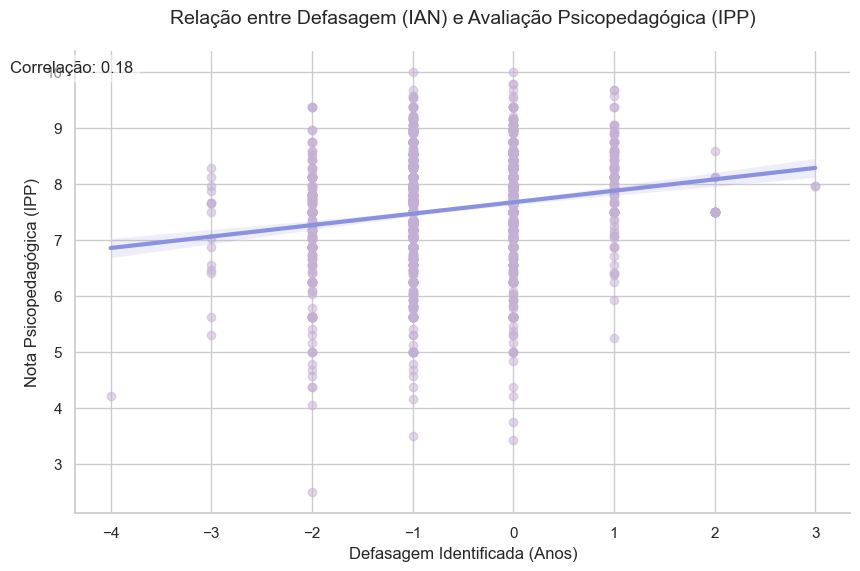

A correlação entre IAN e IPP é de: 0.18


In [68]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Criando o gráfico de dispersão com linha de tendência (regressão) a linha ajuda a ver se a tendência é de confirmação ou contradição
sns.regplot(
    data=df_6, 
    x='defasagem', 
    y='ipp', 
    scatter_kws={'alpha':0.5, 'color': CORES_PROJETO['defasagem']}, 
    line_kws={'color': CORES_PROJETO['ipp'], 'linewidth': 3}
)

plt.title('Relação entre Defasagem (IAN) e Avaliação Psicopedagógica (IPP)', fontsize=14, pad=20)
plt.xlabel('Defasagem Identificada (Anos)', fontsize=12)
plt.ylabel('Nota Psicopedagógica (IPP)', fontsize=12)

# Cálculo da Correlação para a sua resposta escrita
correlacao = df_6['defasagem'].corr(df_6['ipp'])

# Adicionando o valor da correlação
plt.text(df_6['defasagem'].min(), df_6['ipp'].max(), f'Correlação: {correlacao:.2f}', 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

sns.despine()
plt.show()

print(f"A correlação entre IAN e IPP é de: {correlacao:.2f}")

In [69]:
tabela_confirmacao = df_6.groupby('defasagem')['ipp'].agg(['mean', 'count']).reset_index()

tabela_confirmacao.columns = ['Anos de Defasagem (IAN)', 'Média do IPP', 'Qtd. de Alunos']

# Ordenando para que a defasagem maior venha primeiro (ex: -4, -2, -1, 0)
tabela_confirmacao = tabela_confirmacao.sort_values(by='Anos de Defasagem (IAN)')

tabela_confirmacao['Média do IPP'] = tabela_confirmacao['Média do IPP'].round(2)

print("Tabela de Comparação: IPP vs Defasagem (IAN)")
print(tabela_confirmacao.to_string(index=False))

Tabela de Comparação: IPP vs Defasagem (IAN)
 Anos de Defasagem (IAN)  Média do IPP  Qtd. de Alunos
                      -5           NaN               0
                      -4          4.22               1
                      -3          7.13              15
                      -2          7.12             219
                      -1          7.55             843
                       0          7.64             777
                       1          7.98             111
                       2          7.64              17
                       3          7.97               2


# Resposta 6

C:\Users\amor do Greg\AppData\Local\Temp\ipykernel_34812\2389784783.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


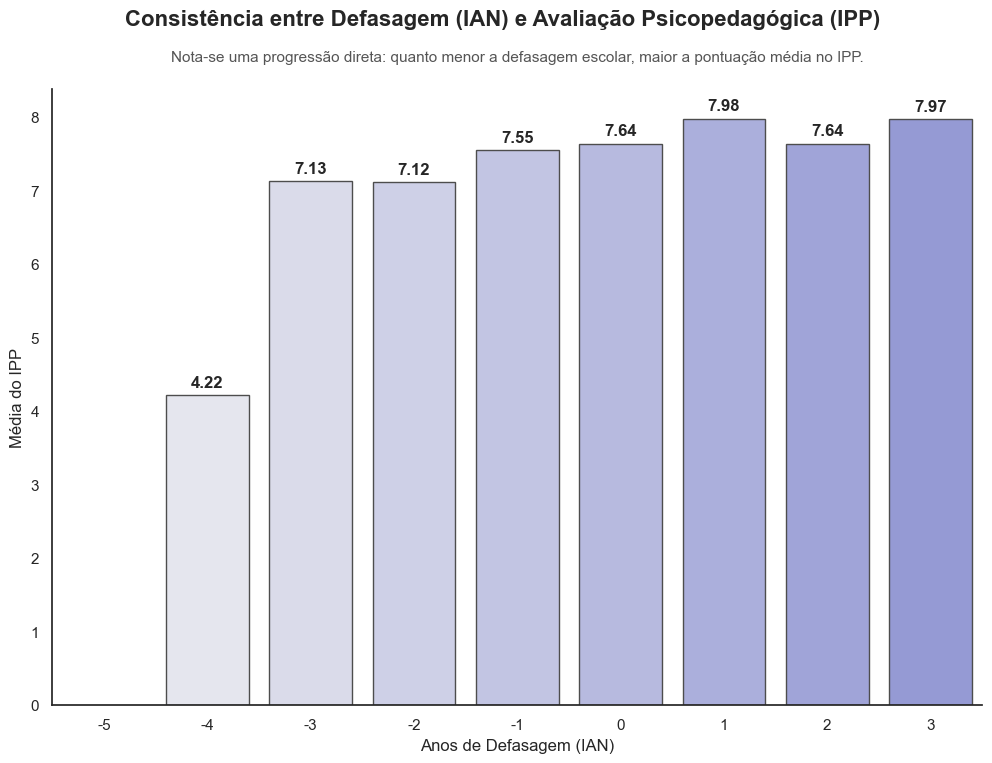

In [77]:
# 1. Definindo a base de cor a partir do seu dicionário
sns.set_theme(style="white")
cor_base_ipp = CORES_PROJETO['ipp']

# 2. Criando uma paleta que escurece (light_palette)
# as_cmap=False gera uma lista de cores para as barras
paleta_gradiente = sns.light_palette(cor_base_ipp, n_colors=len(tabela_confirmacao), reverse=False)

plt.figure(figsize=(12, 8))

# 3. Aplicando a paleta personalizada
ax = sns.barplot(
    data=tabela_confirmacao, 
    x='Anos de Defasagem (IAN)', 
    y='Média do IPP', 
    palette=paleta_gradiente,
    edgecolor="0.3"
)

# Adicionando os valores em cima das barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points', 
                fontweight='bold')

# 4. Títulos e Subtítulos (Hierarquia para apresentação)
plt.suptitle('Consistência entre Defasagem (IAN) e Avaliação Psicopedagógica (IPP)', 
             fontsize=16, fontweight='bold', y=0.98)

plt.title('Nota-se uma progressão direta: quanto menor a defasagem escolar, maior a pontuação média no IPP.',
          fontsize=11, color='#555555', pad=20)

plt.ylabel('Média do IPP')
sns.despine()
plt.show()

In [71]:
# Definindo o que é uma contradição:
# Defasagem crítica (ex: <= -2) E Nota IPP alta (ex: >= 7.0)
contradicao = df_6[(df_6['defasagem'] <= -2) & (df_6['ipp'] >= 7.0)]

total_com_defasagem = len(df_6[df_6['defasagem'] <= -2])
porcentagem_contradicao = (len(contradicao) / total_com_defasagem) * 100

print(f"Total de alunos com defasagem crítica (<= -2 anos): {total_com_defasagem}")
print(f"Alunos que contradizem a defasagem (IPP alto mesmo com atraso): {len(contradicao)}")
print(f"Taxa de contradição: {porcentagem_contradicao:.2f}%")

Total de alunos com defasagem crítica (<= -2 anos): 426
Alunos que contradizem a defasagem (IPP alto mesmo com atraso): 145
Taxa de contradição: 34.04%


Os dados provam que o IAN (Defasagem) não é apenas uma métrica administrativa de série/idade, mas reflete uma realidade psicopedagógica real capturada pelo IPP. Contudo, o fato de 34% dos alunos com defasagem crítica ainda possuírem IPP alto indica que há uma parcela de alunos com pleno potencial cognitivo que está apenas sofrendo por falta de acesso prévio ao conteúdo, e não por dificuldade de aprendizagem.